# 06 — Decoding Press Evaluation

[kvpress evaluation framework](https://github.com/NVIDIA/kvpress/tree/main/evaluation) —
same setup as the [kvpress leaderboard](https://huggingface.co/spaces/nvidia/kvpress-leaderboard).
Four decoding-phase variants using **KeyDiffPress** as base scorer.

## Configuration

In [1]:
import os

os.environ["HF_HOME"] = "/opt/app-root/src/.cache/huggingface"

MODEL_NAME = "Qwen/Qwen3-8B"

# RULER
RULER_DATA_DIR = "16384"

# Shared
COMPRESSION_RATIOS = [0.25, 0.50, 0.75]
FRACTION = 1  # fraction of dataset to evaluate (e.g. 0.1 for quick runs)

PRESS_NAMES = [
    "compression_ratio_decoding_keydiff",
    "uniform_filtering_keydiff",
    "filtering_zerofill_keydiff",
    "filtering_stale_keydiff",
]

FORK_DIR = "/opt/app-root/src/kvpress-fork"
EVAL_DIR = os.path.join(FORK_DIR, "evaluation")
OUTPUT_DIR = os.path.join(os.getcwd(), "results", "kvpress_eval")

SHORT_NAMES = {
    "compression_ratio_decoding_keydiff": "CR Decoding",
    "uniform_filtering_keydiff": "Uniform Filter",
    "filtering_zerofill_keydiff": "Filter (zerofill)",
    "filtering_stale_keydiff": "Filter (stale)",
    "no_press": "No compression",
}

In [2]:
import subprocess

result = subprocess.run(
    ["grep", "-q", "compression_ratio_decoding_keydiff",
     os.path.join(EVAL_DIR, "evaluate_registry.py")],
    capture_output=True,
)
assert result.returncode == 0, (
    f"Evaluation registry at {EVAL_DIR} doesn't contain our press entries. "
    f"Make sure the 'eval' branch is checked out."
)
print(f"Fork: {FORK_DIR}")
print(f"Output: {OUTPUT_DIR}")

Fork: /opt/app-root/src/kvpress-fork
Output: /opt/app-root/src/kvpress-vllm-tests/notebooks/results/kvpress_eval


## 1. Run Evaluations

In [3]:
import sys

env = os.environ.copy()
env["PYTHONPATH"] = FORK_DIR + ":" + env.get("PYTHONPATH", "")

def run_eval(cmd_args, label):
    print(f"\n{'='*60}")
    print(f"Running: {label}")
    print(f"{'='*60}")
    cmd = [sys.executable, "evaluate.py"] + cmd_args + [
        "--model", MODEL_NAME,
        "--output_dir", OUTPUT_DIR,
        "--fraction", str(FRACTION),
    ]
    result = subprocess.run(cmd, cwd=EVAL_DIR, env=env)
    if result.returncode != 0:
        print(f"WARNING: {label} failed (return code {result.returncode})")

### RULER

In [ ]:
run_eval([
    "--dataset", "ruler",
    "--data_dir", RULER_DATA_DIR,
    "--press_name", "no_press",
    "--compression_ratio", "0.0",
], "No compression (baseline)")


Running: No compression (baseline)


/opt/app-root/lib64/python3.12/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/app-root/lib64/python3.12/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


KVzipPress requires multiple forward passes for chunked context reconstruction, resulting in a computational overhead of 2–3 times the initial prefilling cost. This significantly increases the overall prefilling time compared to other compression methods, which is inherent to the KVzip algorithm design.
KVzipPress requires multiple forward passes for chunked context reconstruction, resulting in a computational overhead of 2–3 times the initial prefilling cost. This significantly increases the overall prefilling time compared to other compression methods, which is inherent to the KVzip algorithm design.
2026-08-11 09:29:45,640 - INFO - Set deterministic seeds to 42
2026-08-11 09:29:45,640 - INFO - Initialized EvaluationRunner with config:
{
  "dataset": "ruler",
  "data_dir": 8192,
  "model": "Qwen/Qwen3-8B",
  "device": null,
  "press_name": "no_press",
  "compression_ratio": 0.0,
  "key_channel_compression_ratio": null,
  "head_compression_ratio": null,
  "threshold": null,
  "fractio

In [ ]:
for cr in COMPRESSION_RATIOS:
    run_eval([
        "--dataset", "ruler",
        "--data_dir", RULER_DATA_DIR,
        "--press_name", "compression_ratio_decoding_keydiff",
        "--compression_ratio", str(cr),
    ], f"CR Decoding @ {cr:.2f}")

In [ ]:
for cr in COMPRESSION_RATIOS:
    run_eval([
        "--dataset", "ruler",
        "--data_dir", RULER_DATA_DIR,
        "--press_name", "uniform_filtering_keydiff",
        "--compression_ratio", str(cr),
    ], f"Uniform Filter @ {cr:.2f}")

In [ ]:
for cr in COMPRESSION_RATIOS:
    run_eval([
        "--dataset", "ruler",
        "--data_dir", RULER_DATA_DIR,
        "--press_name", "filtering_zerofill_keydiff",
        "--compression_ratio", str(cr),
    ], f"Filter (zerofill) @ {cr:.2f}")

In [ ]:
for cr in COMPRESSION_RATIOS:
    run_eval([
        "--dataset", "ruler",
        "--data_dir", RULER_DATA_DIR,
        "--press_name", "filtering_stale_keydiff",
        "--compression_ratio", str(cr),
    ], f"Filter (stale) @ {cr:.2f}")

## 2. RULER Results

In [4]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

model_slug = MODEL_NAME.replace("/", "--")
os.makedirs("results", exist_ok=True)

ruler_runs = [("no_press", 0.0)] + [
    (press, cr) for press in PRESS_NAMES for cr in COMPRESSION_RATIOS
]

ruler_rows = []
fraction_suffix = f"__fraction{FRACTION:.3f}" if FRACTION < 1.0 else ""

for press_name, cr in ruler_runs:
    dir_name = f"ruler__{RULER_DATA_DIR}__{model_slug}__{press_name}__{cr:.2f}{fraction_suffix}"
    metrics_path = Path(OUTPUT_DIR) / dir_name / "metrics.json"
    if not metrics_path.exists():
        print(f"Missing: {dir_name}")
        continue
    with open(metrics_path) as f:
        metrics = json.load(f)
    for task, scores in metrics.items():
        ruler_rows.append({
            "press": press_name,
            "compression_ratio": cr,
            "task": task,
            "string_match": scores["string_match"],
        })

ruler_df = pd.DataFrame(ruler_rows)
print(f"RULER: {len(ruler_df)} results, {ruler_df['press'].nunique()} presses, {ruler_df['task'].nunique()} tasks")

RULER: 169 results, 5 presses, 13 tasks


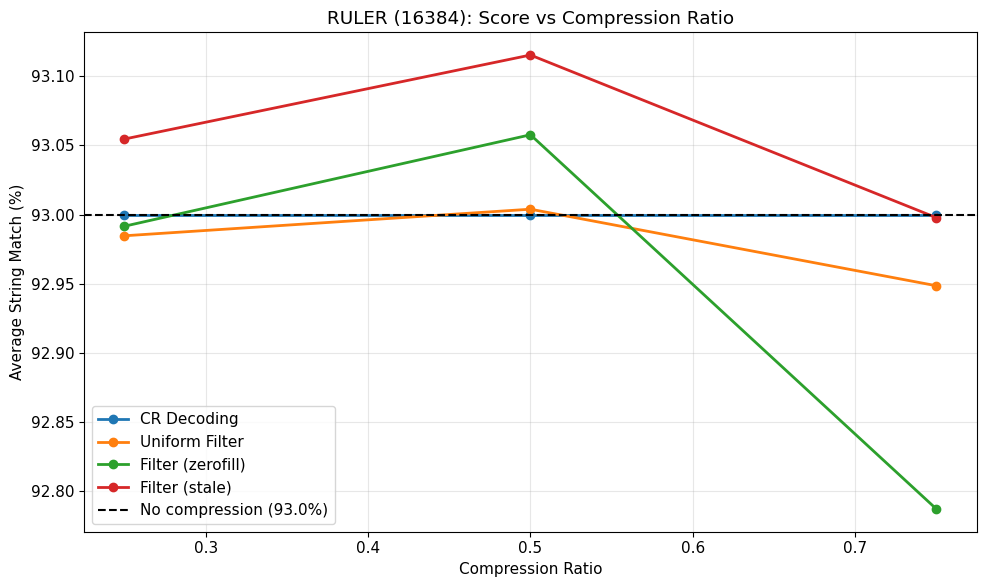

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for press_name in PRESS_NAMES:
    sub = ruler_df[ruler_df["press"] == press_name]
    avg = sub.groupby("compression_ratio")["string_match"].mean().sort_index()
    ax.plot(avg.index, avg.values, marker="o", linewidth=2, label=SHORT_NAMES.get(press_name, press_name))

baseline = ruler_df[ruler_df["press"] == "no_press"]
if not baseline.empty:
    score = baseline["string_match"].mean()
    ax.axhline(score, color="black", linestyle="--", linewidth=1.5, label=f"No compression ({score:.1f}%)")

ax.set_xlabel("Compression Ratio")
ax.set_ylabel("Average String Match (%)")
ax.set_title(f"RULER ({RULER_DATA_DIR}): Score vs Compression Ratio")
ax.legend()
fig.tight_layout()
fig.savefig("results/ruler_score_vs_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

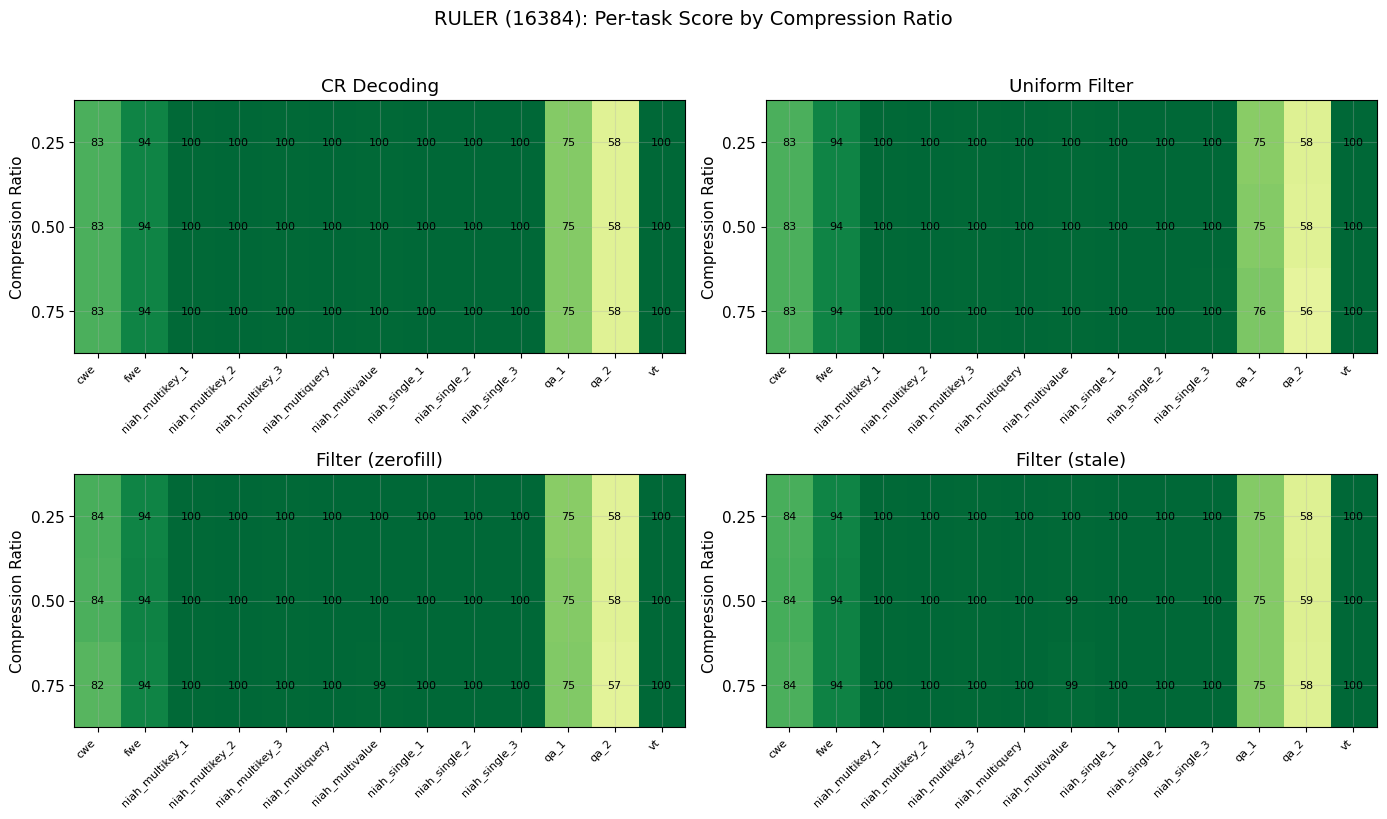

In [6]:
press_df = ruler_df[ruler_df["press"] != "no_press"]
tasks = sorted(press_df["task"].unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 8), squeeze=False)

for idx, press_name in enumerate(PRESS_NAMES):
    row_idx, col_idx = divmod(idx, 2)
    sub = press_df[press_df["press"] == press_name]
    ratios = sorted(sub["compression_ratio"].unique())

    heatmap_data = np.zeros((len(ratios), len(tasks)))
    for i, r in enumerate(ratios):
        for j, t in enumerate(tasks):
            cell = sub[(sub["compression_ratio"] == r) & (sub["task"] == t)]
            heatmap_data[i, j] = cell["string_match"].values[0] if not cell.empty else 0

    ax = axes[row_idx][col_idx]
    ax.imshow(heatmap_data, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(tasks)))
    ax.set_xticklabels(tasks, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(ratios)))
    ax.set_yticklabels([f"{r:.2f}" for r in ratios])
    ax.set_ylabel("Compression Ratio")
    ax.set_title(SHORT_NAMES.get(press_name, press_name))

    for i in range(len(ratios)):
        for j in range(len(tasks)):
            val = heatmap_data[i, j]
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=8,
                    color="white" if val < 50 else "black")

fig.suptitle(f"RULER ({RULER_DATA_DIR}): Per-task Score by Compression Ratio", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig("results/ruler_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Summary

In [7]:
print("RULER")
print("=" * 60)
print(
    ruler_df.assign(press=ruler_df["press"].map(lambda x: SHORT_NAMES.get(x, x)))
    .groupby(["press", "compression_ratio"])
    .agg(avg_score=("string_match", "mean"))
    .round(2)
    .to_string()
)

RULER
                                     avg_score
press             compression_ratio           
CR Decoding       0.25                   93.00
                  0.50                   93.00
                  0.75                   93.00
Filter (stale)    0.25                   93.05
                  0.50                   93.12
                  0.75                   93.00
Filter (zerofill) 0.25                   92.99
                  0.50                   93.06
                  0.75                   92.79
No compression    0.00                   93.00
Uniform Filter    0.25                   92.98
                  0.50                   93.00
                  0.75                   92.95
